# Titanic Survival Prediction – Machine Learning Modeling

**Dataset:** Kaggle Titanic Dataset (891 training passengers, 418 test passengers, 12 features)  
**Objective:** Predict whether a passenger survived (1) or not (0) using passenger attributes such as Age, Gender, Passenger Class, Fare, and Family relationships onboard.  
**Success Metrics:** Accuracy, Precision, Recall, F1-Score, ROC-AUC  

### Workflow
1. **Load & Explore** – Understand the dataset structure and distributions  
2. **Feature Engineering** – Create meaningful features (row-local only, before split)  
3. **Train/Test Split** – 80/20 stratified split **before** any statistical imputation  
4. **Pipeline Construction** – All imputation and scaling inside sklearn Pipelines (no data leakage)  
5. **Model Training & Tuning** – Logistic Regression, Decision Tree, Random Forest with GridSearchCV  
6. **Evaluation** – Confusion matrix, ROC curves, cross-validation, feature importance  
7. **Final Predictions** – Apply best model to truly unseen Kaggle test set  

---

In [1]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, roc_auc_score, precision_score, recall_score, f1_score
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn import set_config
import kagglehub

# plot settings
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

import warnings
warnings.filterwarnings('ignore')

## 1. Dataset Loading

We load both the **training** set (891 passengers with labels) and the **test** set (418 passengers without labels) from Kaggle. The test set serves as truly unseen data for final predictions.

| Column | Description |
|--------|-------------|
| Survived | Target variable (0 = No, 1 = Yes) |
| Pclass | Passenger class (1st, 2nd, 3rd) — proxy for socio-economic status |
| Name, Sex, Age | Personal demographics |
| SibSp, Parch | Family relationships onboard |
| Ticket, Fare, Cabin, Embarked | Travel details |

In [2]:
# loading datasets from kaggle
def load_data():
    """Load the Titanic train and test datasets from Kaggle."""
    path = kagglehub.dataset_download("shuofxz/titanic-machine-learning-from-disaster")
    train_df = pd.read_csv(path + '/train.csv')
    test_df = pd.read_csv(path + '/test.csv')
    return train_df, test_df

df, test_df = load_data()
print(f'Training set shape: {df.shape}')
print(f'Test set shape: {test_df.shape}')
df.head()

100%|██████████| 33.1k/33.1k [00:00<00:00, 33.2MB/s]

Extracting files...
Training set shape: (891, 12)
Test set shape: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Data Exploration & Analysis

In [3]:
# data overview
def explore_data_overview(df):
    """Display basic information about the dataset."""
    print('=== Dataset Info ===')
    print(df.info())
    print('\n=== Statistical Summary ===')
    display(df.describe())
    print('\n=== First Few Rows ===')
    display(df.head())

explore_data_overview(df)

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

=== Statistical Summary ===


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



=== First Few Rows ===


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


=== Missing Values ===


,Missing Count,Missing %
Cabin,687,77.104377
Age,177,19.865320
Embarked,2,0.224467


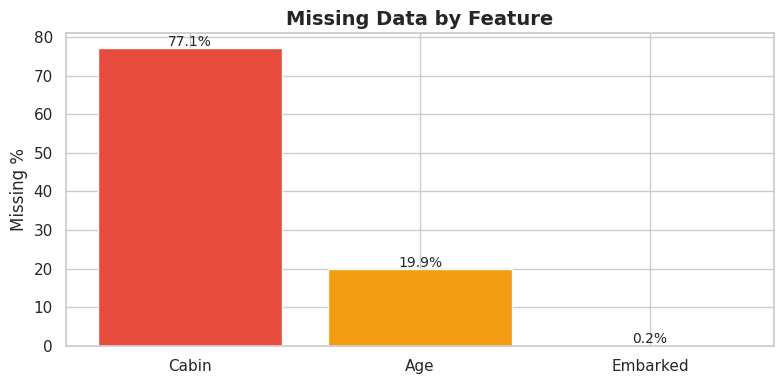

In [4]:
# missing data analysis
def analyze_missing_data(df):
    """Visualize missing values in the dataset."""
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
    missing_df = missing_df.sort_values('Missing %', ascending=False)

    print('=== Missing Values ===')
    display(missing_df[missing_df['Missing Count'] > 0])

    cols_with_missing = missing_df[missing_df['Missing Count'] > 0].index
    if len(cols_with_missing) > 0:
        fig, ax = plt.subplots(figsize=(8, 4))
        bars = ax.bar(cols_with_missing, missing_df.loc[cols_with_missing, 'Missing %'],
                      color=['#e74c3c' if pct > 50 else '#f39c12' if pct > 10 else '#3498db'
                             for pct in missing_df.loc[cols_with_missing, 'Missing %']])
        ax.set_ylabel('Missing %')
        ax.set_title('Missing Data by Feature', fontsize=14, fontweight='bold')
        for bar, pct in zip(bars, missing_df.loc[cols_with_missing, 'Missing %']):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{pct:.1f}%', ha='center', fontsize=10)
        plt.tight_layout()
        plt.savefig('missing_data_analysis.png', dpi=150, bbox_inches='tight')
        plt.show()

analyze_missing_data(df)

**Key Observations:**
- **Cabin**: ~77% missing — too much missing data to impute reliably. We will **drop** this column.
- **Age**: ~20% missing — imputation will be handled **inside the pipeline** using median, fitted only on training data to prevent data leakage.
- **Embarked**: 2 entries missing — handled inside the pipeline using mode imputation.

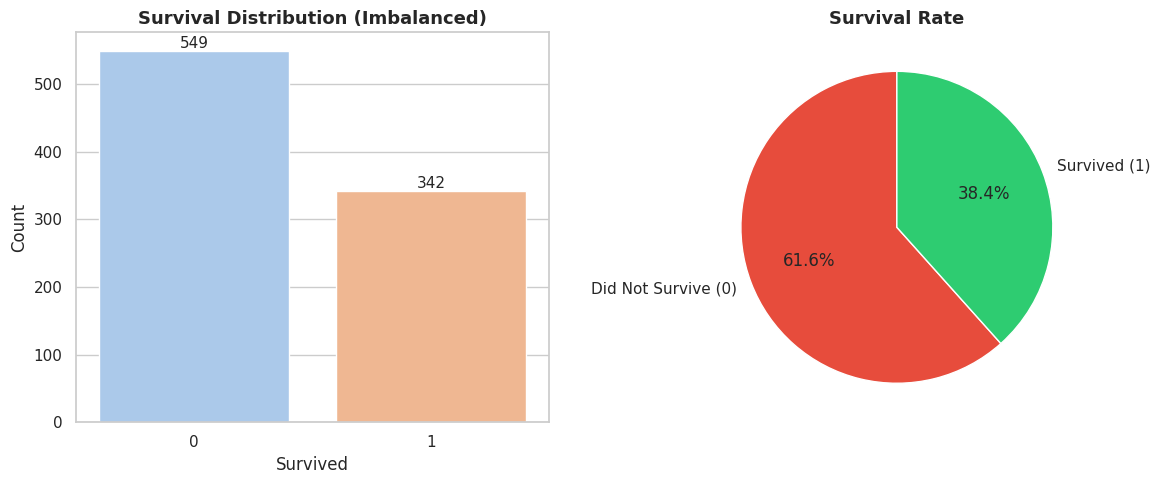


Survival Rate: 38.4%
Death Rate: 61.6%

Note: the dataset is imbalanced (~38% survived, ~62% did not). This is why accuracy alone is insufficient — we also need Precision, Recall, F1, and ROC-AUC.


In [5]:
# target variable analysis
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# survival count
sns.countplot(data=df, x='Survived', palette='pastel', ax=axes[0])
axes[0].set_title('Survival Distribution (Imbalanced)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Survived')
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=11)

# survival percentage
survival_counts = df['Survived'].value_counts()
axes[1].pie(survival_counts, labels=['Did Not Survive (0)', 'Survived (1)'], autopct='%1.1f%%',
            colors=['#e74c3c', '#2ecc71'], startangle=90)
axes[1].set_title('Survival Rate', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('target_variable_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nSurvival Rate: {df["Survived"].mean()*100:.1f}%')
print(f'Death Rate: {(1-df["Survived"].mean())*100:.1f}%')
print('\nNote: the dataset is imbalanced (~38% survived, ~62% did not).',
      'This is why accuracy alone is insufficient — we also need Precision, Recall, F1, and ROC-AUC.')

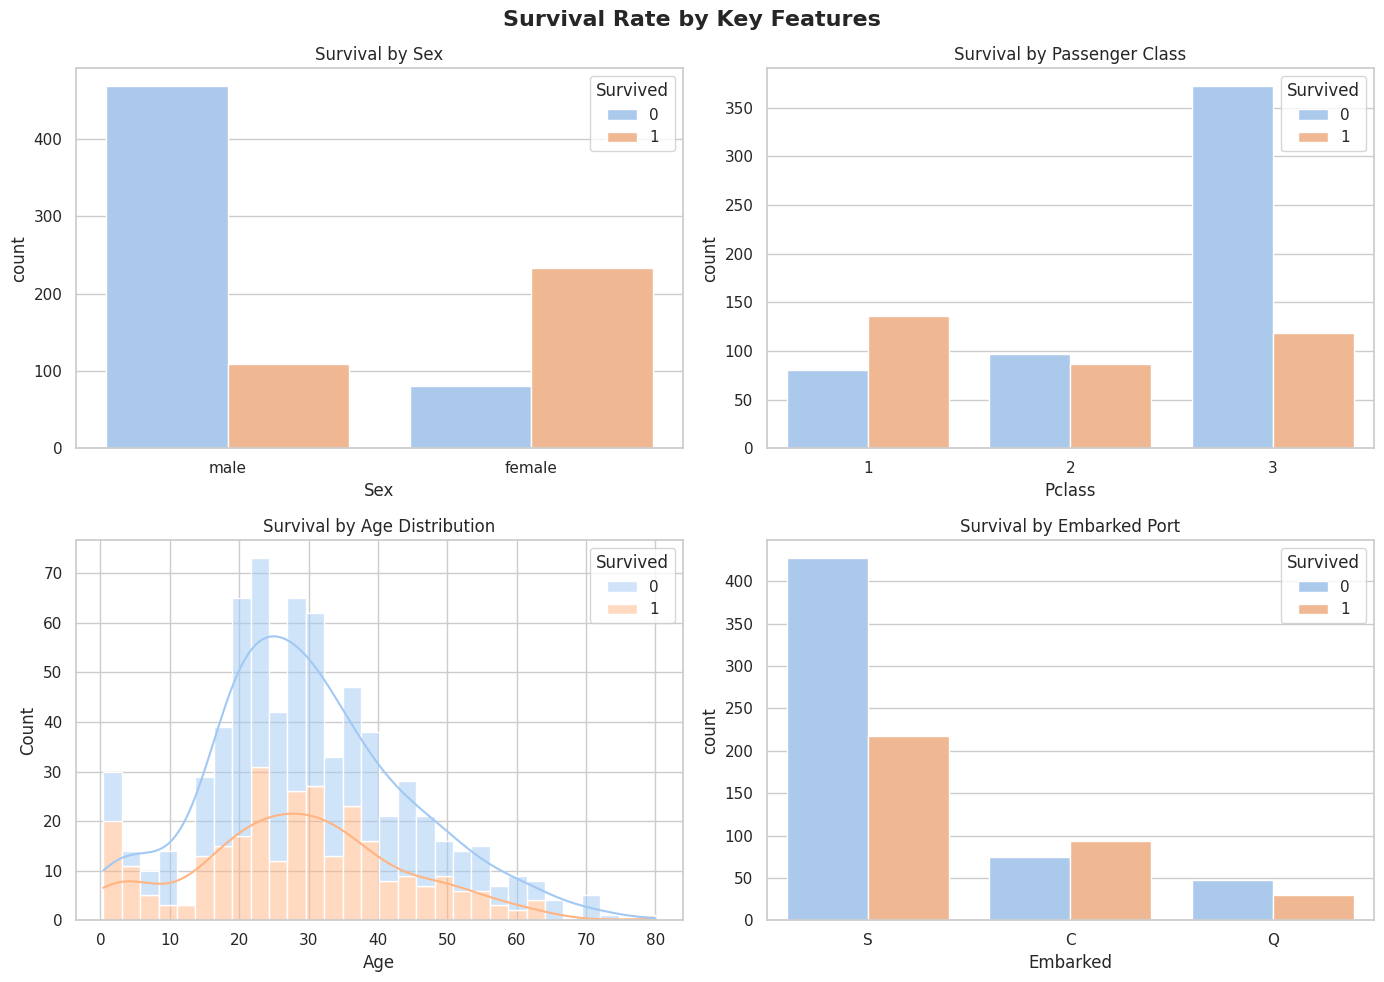

In [6]:
# survival analysis by key features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Survival Rate by Key Features', fontsize=16, fontweight='bold')

# survival by sex
sns.countplot(data=df, x='Sex', hue='Survived', palette='pastel', ax=axes[0, 0])
axes[0, 0].set_title('Survival by Sex')

# survival by class
sns.countplot(data=df, x='Pclass', hue='Survived', palette='pastel', ax=axes[0, 1])
axes[0, 1].set_title('Survival by Passenger Class')

# survival by age distribution
sns.histplot(data=df, x='Age', hue='Survived', kde=True, palette='pastel',
             multiple='stack', ax=axes[1, 0], bins=30)
axes[1, 0].set_title('Survival by Age Distribution')

# survival by embarked
sns.countplot(data=df, x='Embarked', hue='Survived', palette='pastel', ax=axes[1, 1])
axes[1, 1].set_title('Survival by Embarked Port')

plt.tight_layout()
plt.savefig('survival_by_features.png', dpi=150, bbox_inches='tight')
plt.show()

**Key Survival Patterns:**
- **Females** had significantly higher survival probability than males ("women and children first")
- **1st class** passengers survived more often, indicating socio-economic privilege influenced survival
- **Children** (especially young children) had higher survival rates
- **Cherbourg** passengers had a slightly higher survival rate, likely correlated with higher-class passengers boarding there

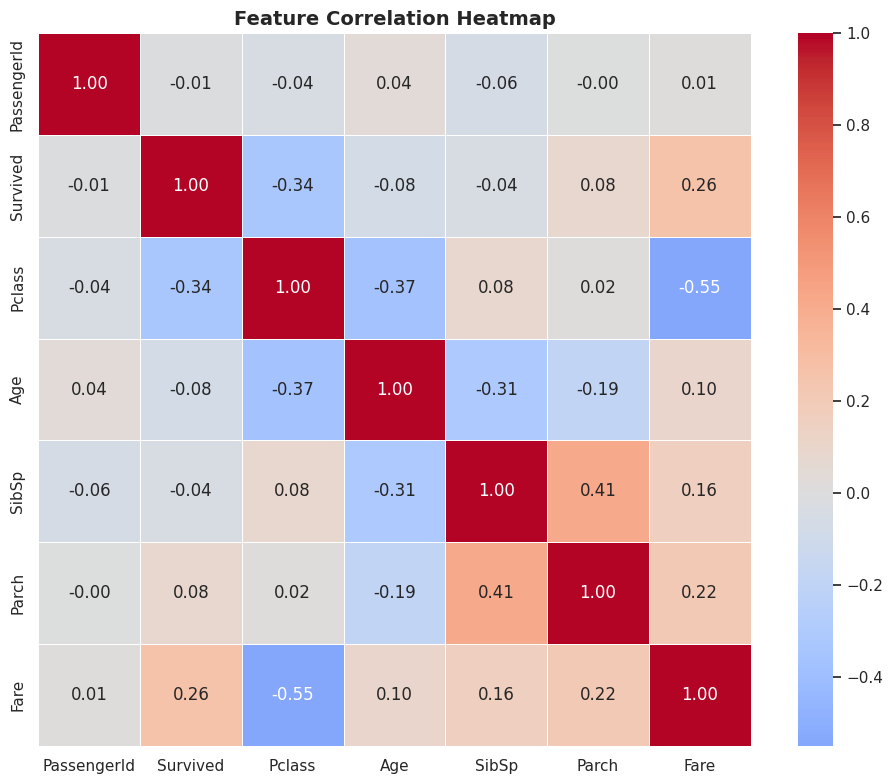

In [7]:
# feature correlation analysis
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', center=0,
            fmt='.2f', linewidths=0.5, square=True)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Feature Engineering (Row-Local — Safe Before Split)

The following features are **row-local**, meaning each row's value depends only on that row's data. These are safe to compute before the train/test split because they don't leak information across samples.

> **Note:** Statistical transformations (Age imputation, Fare scaling, encoding) are handled **inside the sklearn Pipeline** to prevent data leakage. The pipeline fits these transformations only on training data.

In [8]:
# feature engineering — row-local features only (safe before split)

def engineer_features(df):
    """
    Create row-local engineered features.

    These features depend only on each individual row's values,
    so they are safe to compute before train/test split.

    Features created:
    - FamilySize: SibSp + Parch + 1 (total family members aboard)
    - IsAlone: binary flag (1 if FamilySize == 1)
    - Title: extracted from Name, then standardized into common groups
    - FarePerPerson: Fare divided by FamilySize

    NOT computed here (would cause data leakage):
    - Age imputation (median depends on dataset statistics)
    - FareGroup (quartile bins depend on dataset statistics)
    - TicketGroupSize (counts depend on which passengers are in the dataset)
    """
    df = df.copy()

    # --- family size and alone status ---
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

    # --- title extraction from name ---
    df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    df['Title'] = df['Title'].replace(
        ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major',
         'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
    df['Title'] = df['Title'].replace('Mlle', 'Miss')
    df['Title'] = df['Title'].replace('Ms', 'Miss')
    df['Title'] = df['Title'].replace('Mme', 'Mrs')

    # --- fare per person (row-local arithmetic) ---
    df['FarePerPerson'] = df['Fare'] / df['FamilySize']

    print('Engineered Features:')
    print(f'  - FamilySize: min={df["FamilySize"].min()}, max={df["FamilySize"].max()}')
    print(f'  - IsAlone: {df["IsAlone"].value_counts().to_dict()}')
    print(f'  - Title: {df["Title"].value_counts().to_dict()}')
    print(f'  - FarePerPerson: mean={df["FarePerPerson"].mean():.2f}')

    return df

# apply to training data
df = engineer_features(df)

# apply same row-local features to test data
# test_df = engineer_features(test_df)

df.head()

Engineered Features:
  - FamilySize: min=1, max=11
  - IsAlone: {1: 537, 0: 354}
  - Title: {'Mr': 517, 'Miss': 185, 'Mrs': 126, 'Master': 40, 'Rare': 23}
  - FarePerPerson: mean=19.92


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,IsAlone,Title,FarePerPerson
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,0,Mr,3.62500
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,0,Mrs,35.64165
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,1,Miss,7.92500
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,0,Mrs,26.55000
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,1,Mr,8.05000


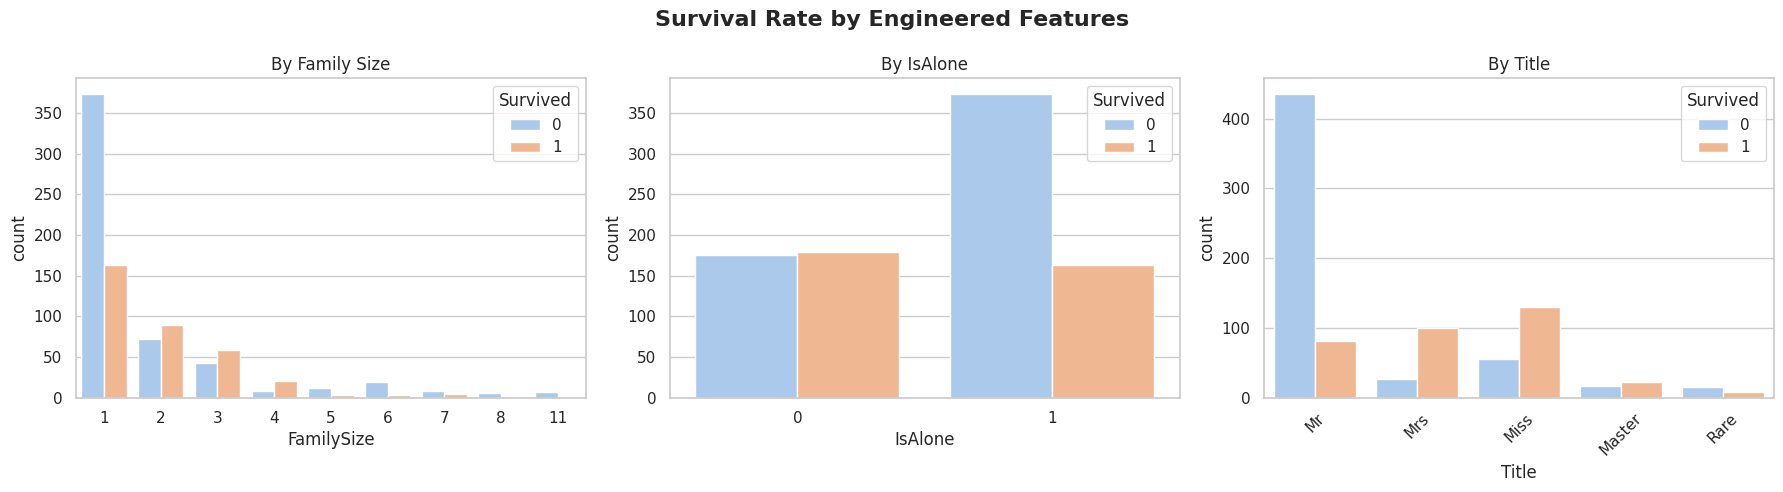

In [9]:
# survival rates by engineered features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Survival Rate by Engineered Features', fontsize=16, fontweight='bold')

sns.countplot(data=df, x='FamilySize', hue='Survived', palette='pastel', ax=axes[0])
axes[0].set_title('By Family Size')

sns.countplot(data=df, x='IsAlone', hue='Survived', palette='pastel', ax=axes[1])
axes[1].set_title('By IsAlone')

sns.countplot(data=df, x='Title', hue='Survived', palette='pastel', ax=axes[2])
axes[2].set_title('By Title')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('engineered_features_survival.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Train/Test Split (Before Any Statistical Preprocessing)

We split the data **before** any statistical transformations (imputation, scaling, encoding) to prevent data leakage. The 80/20 stratified split preserves the class distribution in both sets.

> **Why this matters:** If we impute missing Age values using the median of the entire dataset, the test set's Age values influence the training process. By splitting first and handling imputation inside the Pipeline (which fits only on training data), we ensure the test set remains truly unseen.

In [10]:
# define features and target
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
            'Embarked', 'Title', 'FamilySize', 'IsAlone', 'FarePerPerson']

X = df[features]
y = df['Survived']

# 80/20 stratified split — done BEFORE imputation/scaling to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Validation set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'\nTarget distribution (train): {y_train.value_counts().to_dict()}')
print(f'Target distribution (test):  {y_test.value_counts().to_dict()}')
print(f'\nMissing values in training features:')
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])

Training set: 712 samples (80%)
Validation set: 179 samples (20%)

Target distribution (train): {0: 439, 1: 273}
Target distribution (test):  {0: 110, 1: 69}

Missing values in training features:
Age         137
Embarked      2
dtype: int64


## 5. Pipeline Construction (Leakage-Safe)

The sklearn Pipeline ensures:
1. **Imputation** (Age → median, Embarked → mode) is fitted only on training data
2. **Scaling** (StandardScaler on numeric features) uses only training statistics
3. **Encoding** (OneHotEncoder on categorical features) learns categories from training data only
4. The same transformations are automatically applied to validation/test data at prediction time

In [11]:
# building the preprocessing + model pipeline

# define column groups
numeric_cols = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'FarePerPerson']
categorical_cols = ['Sex', 'Embarked', 'Title']

def build_pipeline(model, numeric_cols, categorical_cols):
    """
    Build a sklearn Pipeline with preprocessing and a classifier.

    Preprocessing (all fitted on training data only):
    - Numeric: SimpleImputer(median) → StandardScaler
    - Categorical: SimpleImputer(most_frequent) → OneHotEncoder

    This prevents data leakage by ensuring no test-set statistics
    influence the training process.
    """
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_cols),
            ('cat', categorical_transformer, categorical_cols)
        ],
        remainder='drop'
    )

    return Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])

# display pipeline architecture
set_config(display='diagram')
sample_pipeline = build_pipeline(LogisticRegression(), numeric_cols, categorical_cols)
sample_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Pclass', 'Age', 'SibSp',
                                                   'Parch', 'Fare',
                                                   'FamilySize', 'IsAlone',
                                                   'FarePerPerson']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Sex', 'Embarked',
                                                   'Title'])])),
                ('classifier', LogisticRegression())])

## 6. Model Training & Hyperparameter Tuning

We train three models using **GridSearchCV** with 5-fold cross-validation on the training set only. The pipeline ensures that preprocessing is re-fitted on each CV fold's training portion.

In [12]:
# model training and evaluation

def train_and_evaluate(models_and_params, X_train, X_test, y_train, y_test,
                       numeric_cols, categorical_cols):
    """
    Train models with GridSearchCV and evaluate on validation set.

    For each model:
    1. Builds a pipeline (preprocessor + classifier)
    2. Runs GridSearchCV with 5-fold CV on training data
    3. Evaluates best model on validation set
    4. Computes metrics: accuracy, precision, recall, f1, roc-auc
    5. Runs 10-fold CV for stability estimate
    """
    results = {}
    best_models = {}

    for name, config in models_and_params.items():
        print(f'\n{"="*60}')
        print(f'Training: {name}')
        print(f'{"="*60}')

        pipeline = build_pipeline(config['model'], numeric_cols, categorical_cols)

        grid = GridSearchCV(
            pipeline, config['params'],
            cv=5, scoring='accuracy', n_jobs=-1, verbose=0
        )
        grid.fit(X_train, y_train)

        best_pipeline = grid.best_estimator_
        best_models[name] = best_pipeline

        # predictions
        y_pred = best_pipeline.predict(X_test)
        y_pred_proba = best_pipeline.predict_proba(X_test)[:, 1]

        # metrics
        train_acc = best_pipeline.score(X_train, y_train)
        test_acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_pred_proba)

        # 10-fold cross-validation on training data
        cv_scores = cross_val_score(best_pipeline, X_train, y_train, cv=10, scoring='accuracy')

        results[name] = {
            'Best Params': grid.best_params_,
            'Train Accuracy': train_acc,
            'Test Accuracy': test_acc,
            'Precision': prec,
            'Recall': rec,
            'F1-Score': f1,
            'ROC-AUC': auc,
            'CV Mean': cv_scores.mean(),
            'CV Std': cv_scores.std(),
            'y_pred_proba': y_pred_proba,
            'y_pred': y_pred
        }

        print(f'Best Parameters: {grid.best_params_}')
        print(f'Train Accuracy: {train_acc:.4f}')
        print(f'Test Accuracy:  {test_acc:.4f}')
        print(f'Overfitting Gap: {train_acc - test_acc:.4f}')
        print(f'10-Fold CV: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')
        print(f'\nClassification Report:')
        print(classification_report(y_test, y_pred))

    return results, best_models

# define models and hyperparameter grids
models_and_params = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, random_state=42),
        'params': {
            'classifier__C': [0.01, 0.1, 1, 10],
            'classifier__solver': ['liblinear', 'lbfgs']
        }
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {
            'classifier__max_depth': [None, 5, 10, 15],
            'classifier__min_samples_split': [2, 5, 10],
            'classifier__min_samples_leaf': [1, 2, 4]
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'classifier__n_estimators': [50, 100, 200],
            'classifier__max_depth': [None, 5, 10],
            'classifier__min_samples_split': [2, 5, 10]
        }
    }
}

results, best_models = train_and_evaluate(
    models_and_params, X_train, X_test, y_train, y_test, numeric_cols, categorical_cols)


Training: Logistic Regression
Best Parameters: {'classifier__C': 10, 'classifier__solver': 'lbfgs'}
Train Accuracy: 0.8301
Test Accuracy:  0.8547
Overfitting Gap: -0.0247
10-Fold CV: 0.8175 (+/- 0.0395)

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.91      0.88       110
           1       0.84      0.77      0.80        69

    accuracy                           0.85       179
   macro avg       0.85      0.84      0.84       179
weighted avg       0.85      0.85      0.85       179


Training: Decision Tree
Best Parameters: {'classifier__max_depth': 5, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 10}
Train Accuracy: 0.8750
Test Accuracy:  0.7821
Overfitting Gap: 0.0929
10-Fold CV: 0.8217 (+/- 0.0399)

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.89      0.83       110
           1       0.78      0.61      0.68        69

    accuracy

## 7. Model Evaluation & Visualization

### 7.1 Confusion Matrices
Each matrix shows True Negatives (top-left), False Positives (top-right), False Negatives (bottom-left), and True Positives (bottom-right).

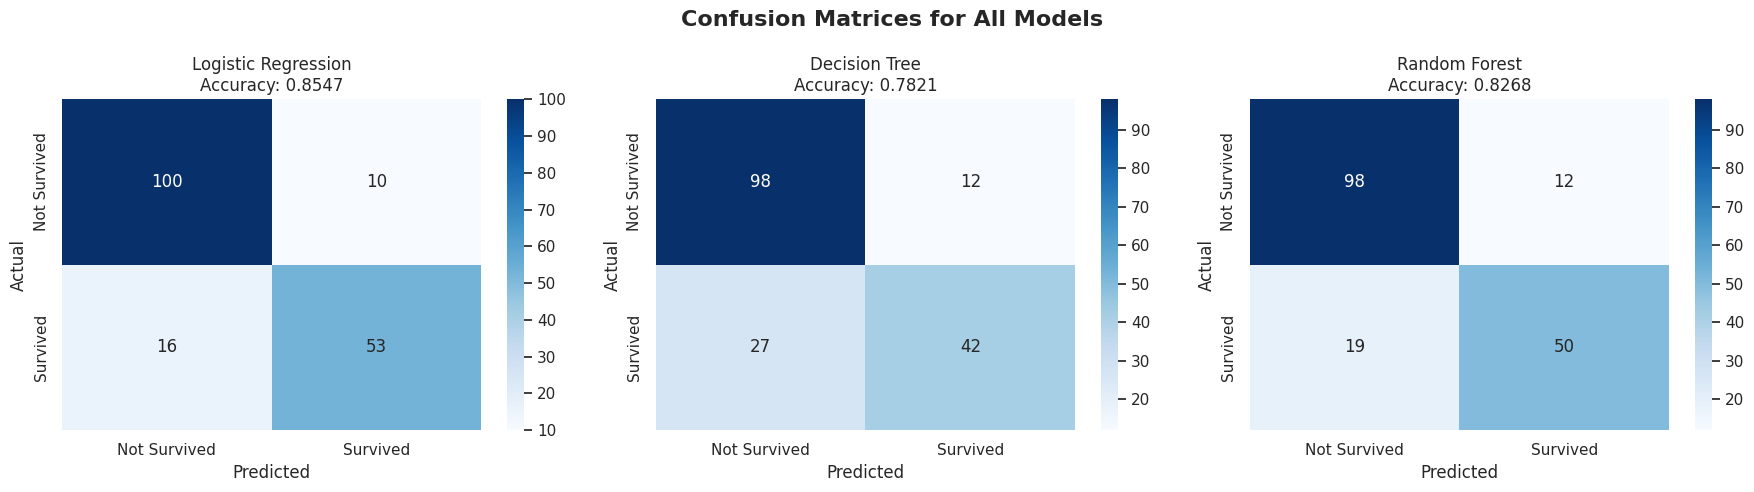

In [13]:
# confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices for All Models', fontsize=16, fontweight='bold')

for idx, (name, metrics) in enumerate(results.items()):
    cm = confusion_matrix(y_test, metrics['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Not Survived', 'Survived'],
                yticklabels=['Not Survived', 'Survived'])
    axes[idx].set_title(f'{name}\nAccuracy: {metrics["Test Accuracy"]:.4f}')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.2 ROC Curves
The ROC curve plots the True Positive Rate against the False Positive Rate at various thresholds. A model with AUC closer to 1.0 is better at distinguishing between classes.

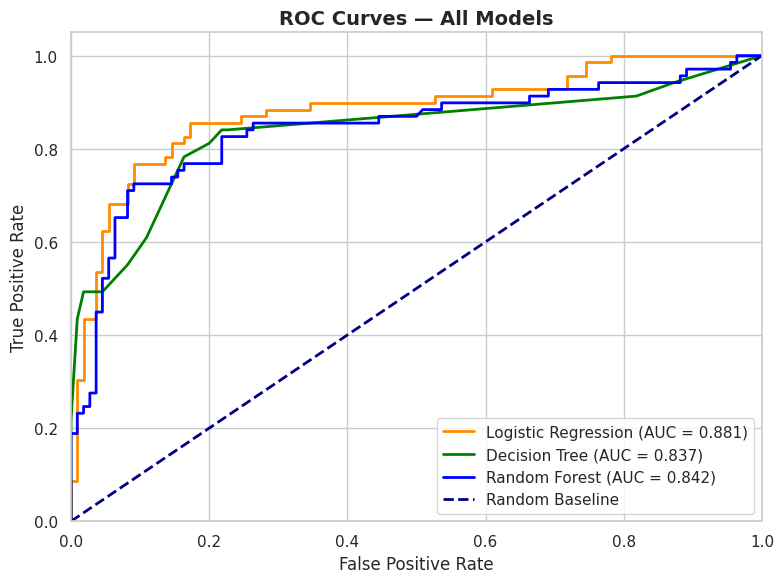

In [14]:
# ROC curve comparison for all models
plt.figure(figsize=(8, 6))
colors = ['darkorange', 'green', 'blue']

for idx, (name, metrics) in enumerate(results.items()):
    fpr, tpr, _ = roc_curve(y_test, metrics['y_pred_proba'])
    auc_score = metrics['ROC-AUC']
    plt.plot(fpr, tpr, color=colors[idx], lw=2,
             label=f'{name} (AUC = {auc_score:.3f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Baseline')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.savefig('roc_curves_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.3 Model Comparison Summary

In [15]:
# model comparison summary table
def plot_model_comparison(results):
    """Create a comprehensive model comparison table."""
    comparison = pd.DataFrame({
        name: {
            'Train Accuracy': f'{m["Train Accuracy"]:.4f}',
            'Test Accuracy': f'{m["Test Accuracy"]:.4f}',
            'Overfit Gap': f'{m["Train Accuracy"] - m["Test Accuracy"]:.4f}',
            'Precision': f'{m["Precision"]:.4f}',
            'Recall': f'{m["Recall"]:.4f}',
            'F1-Score': f'{m["F1-Score"]:.4f}',
            'ROC-AUC': f'{m["ROC-AUC"]:.4f}',
            '10-Fold CV': f'{m["CV Mean"]:.4f} ± {m["CV Std"]:.4f}'
        } for name, m in results.items()
    })

    print('\n=== Model Comparison Summary ===')
    display(comparison)
    return comparison

comparison = plot_model_comparison(results)


=== Model Comparison Summary ===


,Logistic Regression,Decision Tree,Random Forest
Train Accuracy,0.8301,0.8750,0.9045
Test Accuracy,0.8547,0.7821,0.8268
Overfit Gap,-0.0247,0.0929,0.0777
Precision,0.8413,0.7778,0.8065
Recall,0.7681,0.6087,0.7246
F1-Score,0.8030,0.6829,0.7634
ROC-AUC,0.8809,0.8373,0.8424
10-Fold CV,0.8175 ± 0.0395,0.8217 ± 0.0399,0.8204 ± 0.0452


### 7.4 Overfitting Analysis

A large gap between **Train Accuracy** and **Test Accuracy** indicates overfitting. Cross-validation provides a more robust estimate of generalization performance.

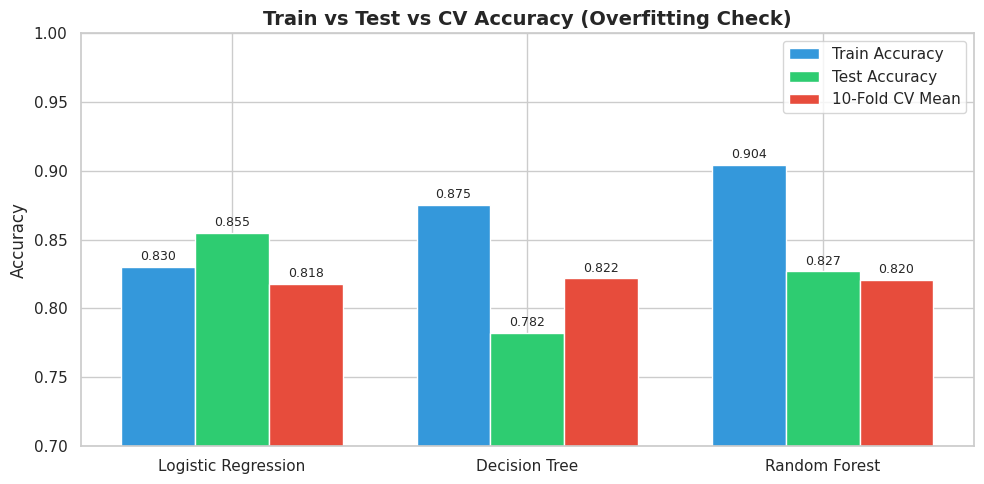

In [16]:
# overfitting analysis bar chart
fig, ax = plt.subplots(figsize=(10, 5))

models = list(results.keys())
train_accs = [results[m]['Train Accuracy'] for m in models]
test_accs = [results[m]['Test Accuracy'] for m in models]
cv_means = [results[m]['CV Mean'] for m in models]

x = np.arange(len(models))
width = 0.25

ax.bar(x - width, train_accs, width, label='Train Accuracy', color='#3498db')
ax.bar(x, test_accs, width, label='Test Accuracy', color='#2ecc71')
ax.bar(x + width, cv_means, width, label='10-Fold CV Mean', color='#e74c3c')

ax.set_ylabel('Accuracy')
ax.set_title('Train vs Test vs CV Accuracy (Overfitting Check)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0.7, 1.0)

for i, (tr, te, cv) in enumerate(zip(train_accs, test_accs, cv_means)):
    ax.text(i - width, tr + 0.005, f'{tr:.3f}', ha='center', fontsize=9)
    ax.text(i, te + 0.005, f'{te:.3f}', ha='center', fontsize=9)
    ax.text(i + width, cv + 0.005, f'{cv:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('overfitting_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.5 Feature Importance

We analyze feature importance for two models:
- **Logistic Regression**: absolute coefficient values (higher = more influence)
- **Random Forest**: built-in Gini importance (measures how much each feature reduces impurity)

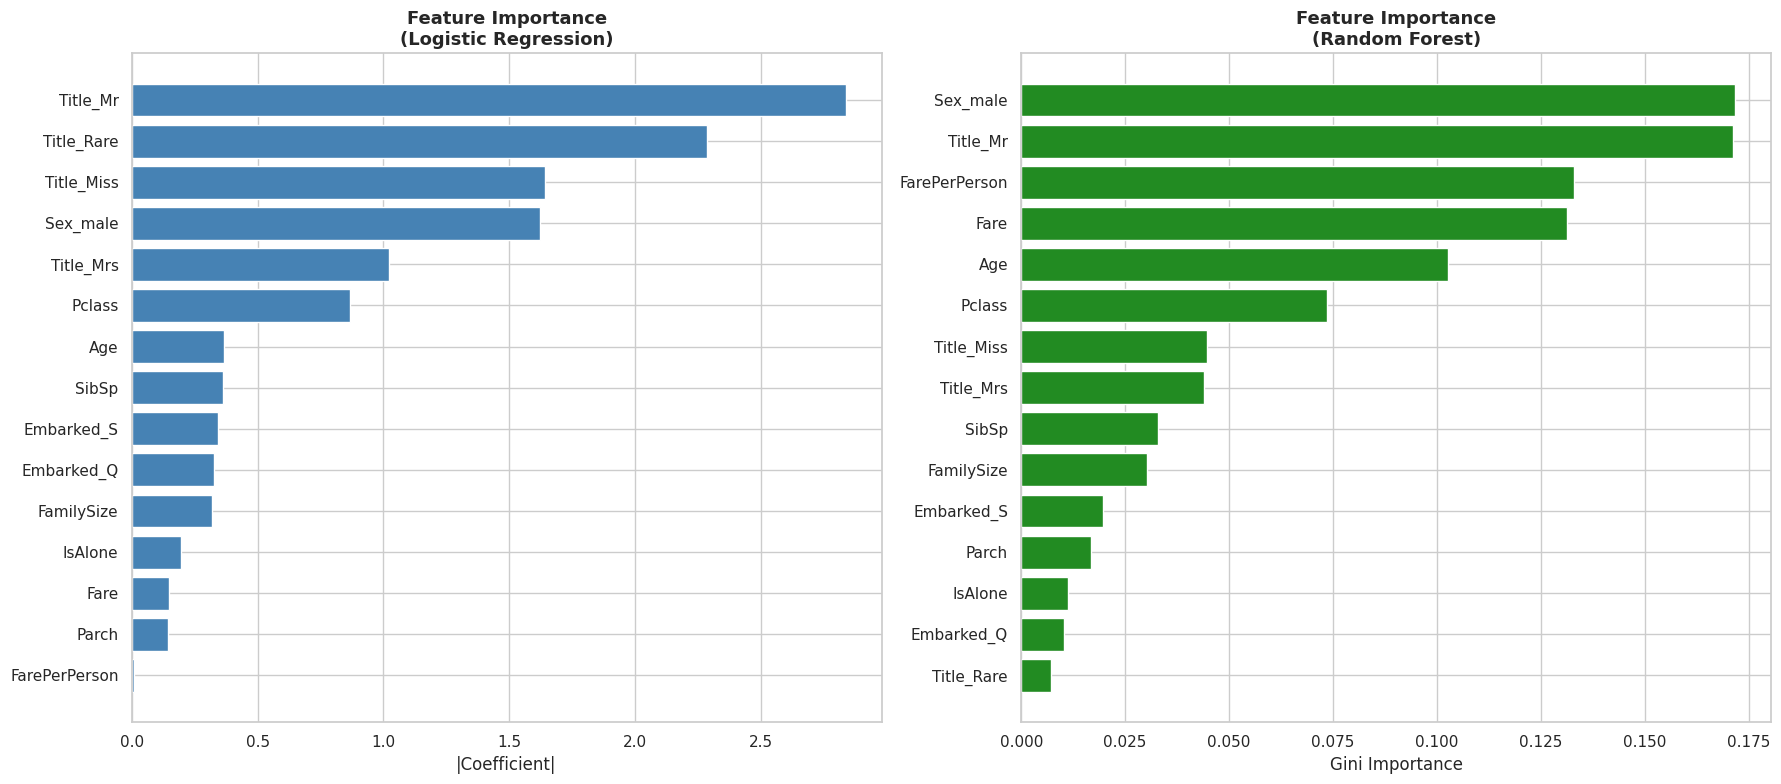

In [17]:
# feature importance for logistic regression and random forest

def get_feature_names(pipeline, numeric_cols, categorical_cols):
    """Extract feature names from the fitted pipeline's preprocessor."""
    preprocessor = pipeline.named_steps['preprocessor']
    cat_features = list(preprocessor.named_transformers_['cat']
                        .named_steps['encoder']
                        .get_feature_names_out(categorical_cols))
    return list(numeric_cols) + cat_features

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- logistic regression feature importance ---
lr_pipeline = best_models['Logistic Regression']
lr_model = lr_pipeline.named_steps['classifier']
feature_names = get_feature_names(lr_pipeline, numeric_cols, categorical_cols)

importances_lr = np.abs(lr_model.coef_[0])
feat_imp_lr = pd.DataFrame({'Feature': feature_names, 'Importance': importances_lr})
feat_imp_lr = feat_imp_lr.sort_values('Importance', ascending=True)

axes[0].barh(feat_imp_lr['Feature'], feat_imp_lr['Importance'], color='steelblue')
axes[0].set_xlabel('|Coefficient|')
axes[0].set_title('Feature Importance\n(Logistic Regression)', fontsize=13, fontweight='bold')

# --- random forest feature importance ---
rf_pipeline = best_models['Random Forest']
rf_model = rf_pipeline.named_steps['classifier']

importances_rf = rf_model.feature_importances_
feat_imp_rf = pd.DataFrame({'Feature': feature_names, 'Importance': importances_rf})
feat_imp_rf = feat_imp_rf.sort_values('Importance', ascending=True)

axes[1].barh(feat_imp_rf['Feature'], feat_imp_rf['Importance'], color='forestgreen')
axes[1].set_xlabel('Gini Importance')
axes[1].set_title('Feature Importance\n(Random Forest)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Final Predictions on Truly Unseen Data

We select the best-performing model based on validation metrics and apply it to the **Kaggle test set** (`test.csv`) — data the model has never seen during training or validation.

This is different from the validation split used above:
- **Validation set** (20% of `train.csv`): used during development to compare models
- **Test set** (`test.csv`): truly unseen data for final submission

In [18]:
# select best model and predict on unseen test data

# pick the model with the best validation accuracy
best_model_name = max(results, key=lambda k: results[k]['Test Accuracy'])
final_model = best_models[best_model_name]

print(f'Best Model: {best_model_name}')
print(f'Validation Accuracy: {results[best_model_name]["Test Accuracy"]:.4f}')
print(f'ROC-AUC: {results[best_model_name]["ROC-AUC"]:.4f}')
print(f'F1-Score: {results[best_model_name]["F1-Score"]:.4f}')

# prepare test data — apply same row-local features (already done above)
# handle missing Fare in test set (1 missing value)

# Apply feature engineering to test_df before selecting features
test_df = engineer_features(test_df)

test_features = test_df[features].copy()

# generate final predictions on truly unseen data
final_predictions = final_model.predict(test_features)

# create submission file
submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Survived': final_predictions
})

submission.to_csv('titanic_submission.csv', index=False)
print(f"\nSuccessfully created 'titanic_submission.csv' with {len(submission)} predictions!")
print(f'Predicted survival rate: {final_predictions.mean()*100:.1f}%')
display(submission.head(10))

Best Model: Logistic Regression
Validation Accuracy: 0.8547
ROC-AUC: 0.8809
F1-Score: 0.8030
Engineered Features:
  - FamilySize: min=1, max=11
  - IsAlone: {1: 253, 0: 165}
  - Title: {'Mr': 240, 'Miss': 79, 'Mrs': 72, 'Master': 21, 'Rare': 6}
  - FarePerPerson: mean=21.80

Successfully created 'titanic_submission.csv' with 418 predictions!
Predicted survival rate: 39.2%


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
5,897,0
6,898,1
7,899,0
8,900,1
9,901,0


## 9. Key Findings & Summary

### Survival Patterns Discovered

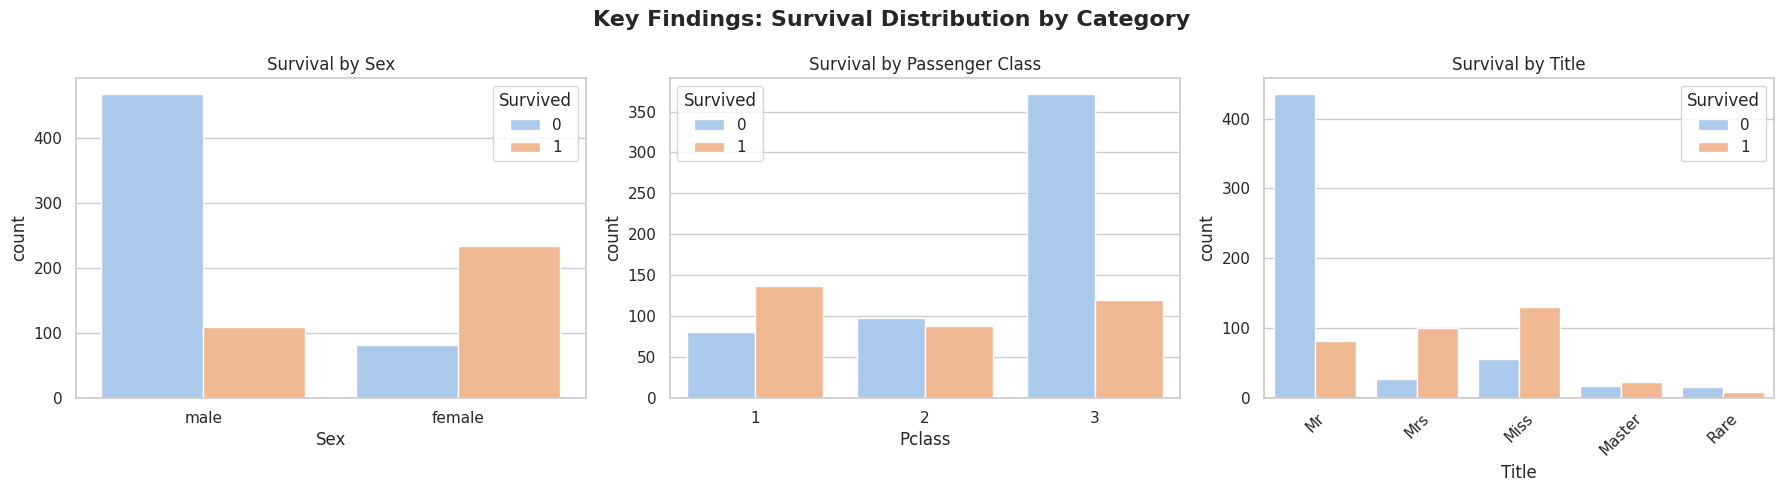

In [19]:
# key findings visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Key Findings: Survival Distribution by Category', fontsize=16, fontweight='bold')

# survival by sex
sns.countplot(data=df, x='Sex', hue='Survived', palette='pastel', ax=axes[0])
axes[0].set_title('Survival by Sex', fontsize=12)

# survival by class
sns.countplot(data=df, x='Pclass', hue='Survived', palette='pastel', ax=axes[1])
axes[1].set_title('Survival by Passenger Class', fontsize=12)

# survival by title
sns.countplot(data=df, x='Title', hue='Survived', palette='pastel', ax=axes[2])
axes[2].set_title('Survival by Title', fontsize=12)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [20]:
# display final pipeline architecture
set_config(display='diagram')
final_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Pclass', 'Age', 'SibSp',
                                                   'Parch', 'Fare',
                                                   'FamilySize', 'IsAlone',
                                                   'FarePerPerson']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Sex', 'Embarked',
                                                   'Title'])])),
                ('classifier',
                 LogisticRegression(C=10, max_iter=1000, random_state=42))])

## 10. Limitations & Future Improvements

### Current Limitations
1. **Dataset size**: only 891 training samples — small for complex models, may not generalize well to other maritime disaster scenarios.
2. **Missing data**: Age is missing for ~20% of passengers. While median imputation within the pipeline prevents leakage, it may not capture the true age distribution (e.g., younger passengers in 3rd class may be disproportionately missing).
3. **Feature scope**: some potentially useful features were dropped:
   - **Cabin**: 77% missing, but the deck letter (first character) could encode location on ship.
   - **Ticket number patterns**: may encode group bookings or ticket class sub-categories.
4. **No ensemble/stacking**: we compared individual models but did not try model ensembling (e.g., VotingClassifier, Stacking) which could improve performance.
5. **Class imbalance**: the dataset is moderately imbalanced (38% survived). While we evaluate with F1 and ROC-AUC, we did not apply techniques like SMOTE or class weighting.
6. **Hyperparameter space**: GridSearchCV was used with relatively small parameter grids. A wider search (or RandomizedSearchCV / Bayesian optimization) could find better hyperparameters.

### Future Improvements
- Extract **Cabin deck** (first letter of Cabin) as a feature for the ~23% of passengers who have it
- Try **gradient boosting** models (XGBoost, LightGBM) which often perform well on tabular data
- Implement **class weighting** or **SMOTE** to handle imbalance more explicitly
- Use **Bayesian hyperparameter optimization** (e.g., Optuna) for more efficient tuning
- Add **SHAP analysis** for more interpretable feature importance explanations